In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "3"

import jax
print(f"JAX devices: {jax.devices()}")

from importlib import reload
from importlib.resources import files, as_file

import numpy as np
import jax
import recovar
from recovar import (
    plot_utils, 
    output,
    simulator,
    utils,
    dataset,
    em,
    regularization, 
    synthetic_dataset,
    utils,
    noise

)
import time
import matplotlib.pyplot as plt
import seaborn as sns

reload(simulator)

# Dataset parameters
grid_size = 64
n_images = 1000
generate_data = True
noise_level = 1

# Input/output paths
volume_folder_input = str(files(recovar) / "data" / "vol")
output_folder = "/tmp/em_test/"

# Dataset generation parameters
volume_distribution = None #np.array([1, 0, 0])
voxel_size = 4.25 * 128 / grid_size

# Create output directory
output.mkdir_safe(output_folder)

if generate_data:
    image_stack, sim_info = simulator.generate_synthetic_dataset(output_folder, voxel_size, volume_folder_input, n_images,
                                                                    outlier_file_input = None, grid_size = grid_size,
                                    volume_distribution = volume_distribution,  dataset_params_option = "uniform", noise_level = noise_level,
                                    noise_model = "white", put_extra_particles = False, percent_outliers = 0.00, 
                                    volume_radius = 0.7, trailing_zero_format_in_vol_name = True, noise_scale_std =0, contrast_std = 0  , disc_type = 'nearest', n_tilts = -1 )
    print(f"Finished generating dataset {output_folder}")


JAX devices: [CudaDevice(id=0)]
Finished generating dataset /tmp/em_test/


In [2]:
# Set up rotations and translation grids
healpix_order = 3
angles = em.sampling.get_rotation_grid(healpix_order)
rotation_grid = utils.R_from_relion(angles)
translation_grid = em.sampling.get_translation_grid(2, 1)

# Load dataset
dataset_dict = dataset.get_default_dataset_option()
dataset_dict.update({
    'ctf_file': output_folder + "ctf.pkl",
    'poses_file': output_folder + "poses.pkl", 
    'particles_file': f"{output_folder}particles.{grid_size}.mrcs"
})
cryo = dataset.load_dataset_from_dict(dataset_dict, lazy=False)

# Load ground truth data
sim_info = utils.pickle_load(output_folder + '/simulation_info.pkl')
gt_recon = synthetic_dataset.load_heterogeneous_reconstruction(sim_info)
gt_vol = gt_recon.volumes
noise_variance = sim_info['noise_variance']

# Get mean volume and signal variance
gt_results = synthetic_dataset.load_heterogeneous_reconstruction(sim_info)
mean_estimate = gt_results.get_mean()
# signal_variance_radial = regularization.average_over_shells(np.abs(gt_vol)**2, gt_results.volume_shape) 
# signal_variance = utils.make_radial_image(signal_variance_radial, gt_results.volume_shape)

ind_split = [np.arange(n_images//2), np.arange(n_images//2, n_images)]
del dataset_dict['ind']
cryos = dataset.get_split_datasets_from_dict(dataset_dict, ind_split, False)

for cryo in cryos:
    cryo.set_radial_noise_model(noise_variance)


In [3]:
import jax.numpy as jnp
U_initial, s_initial, _ = gt_results.get_vol_svd() 
U_initial = U_initial[:,:-1]
s_initial = s_initial[:-1]
# Square root of covar
W_initial = U_initial * s_initial[None]

w_gt_averaged = regularization.batch_average_over_shells(jnp.abs(W_initial.T)**2, gt_results.volume_shape, 0 )
W_prior = utils.batch_make_radial_image(w_gt_averaged, gt_results.volume_shape, True).T


In [4]:
from recovar import covariance_estimation, homogeneous, principal_components
reload(covariance_estimation)
def make_algorithm_options():
    options = {'volume_mask_option': None,
    'zs_dim_to_test': [10,],
    'contrast' : "none",
    'ignore_zero_frequency' : False ,
    'keep_intermediate' : False ,
    }
    return options
valid_idx = cryo.get_valid_frequency_indices()

options = make_algorithm_options()
batch_size = 500
noise_variance = utils.make_radial_image(noise_variance, cryos[0].image_shape)
covariance_options = covariance_estimation.get_default_covariance_computation_options(cryos[0].grid_size)
means, mean_prior, _  = homogeneous.get_mean_conformation_relion(cryos, 2*batch_size, noise_variance = noise_variance,  use_regularization = False)
variance_est, _, variance_fsc, _, noise_p_variance_est = covariance_estimation.compute_variance(cryos, mean_estimate, batch_size//2, None, use_regularization = True, disc_type = 'cubic')

u = {}
s = {}


focus_mask = np.ones(cryos[0].volume_shape)
dilated_volume_mask = np.ones(cryos[0].volume_shape)
u_this,s_this, covariance_cols, picked_frequencies, column_fscs = principal_components.estimate_principal_components(cryos, options, means, mean_prior, focus_mask, dilated_volume_mask, valid_idx, batch_size, gpu_memory_to_use=40, covariance_options = covariance_options, variance_estimate = variance_est['combined'], use_reg_mean_in_contrast = False)
u_covar = u_this['rescaled']
s_covar = s_this['rescaled']

W_prior_from_covar = u_covar * np.sqrt(s_covar)[None]

--------------------------------
--------------------------------
mask_images_in_proj changed
mask_images_in_proj changed
--------------------------------
--------------------------------


Applying mask in post_proces_from_filter_v2


In [5]:
from recovar import ppca
from recovar import fourier_transform_utils 
ftu = fourier_transform_utils.fourier_transform_utils(jnp)


reload(ppca)
W_initial = np.random.randn(*W_prior.shape).T
W_initial = W_initial.reshape(W_initial.shape[0], *cryos[0].volume_shape)
W_initial = ftu.get_dft3(W_initial).reshape(W_initial.shape[0], -1).T

# u_ppca, s_ppca, W, expected_zs, second_moment_zs = ppca.EM(cryos, mean_estimate, W_initial , W_prior * 1e-1 )

for k in np.arange(-0, 1,1):
    u_ppca, s_ppca, W, expected_zs, second_moment_zs = ppca.EM(cryos, mean_estimate, W_initial , W_prior * 10.0**(k) )
    u['ppca_'+str(k)] = u_ppca
    s['ppca_'+str(k)] = s_ppca



/home/mg6942/.conda/envs/recovar_dev/lib/python3.11/site-packages/jax/_src/ops/scatter.py:92: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=complex64 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


np.mean(expected_zs, axis=0), np.var(expected_zs, axis=0) [7.41534408e-05+9.14551375e-06j 8.80110338e-05-2.37555365e-06j] [8.26874320e-06 7.70338563e-06]
Done with EM step 0
np.mean(expected_zs, axis=0), np.var(expected_zs, axis=0) [0.00047056+1.08680090e-06j 0.00034694-2.25763047e-07j] [0.00196757 0.00010437]
Done with EM step 1
np.mean(expected_zs, axis=0), np.var(expected_zs, axis=0) [7.44340178e-05+1.57144659e-05j 1.31410688e-03+7.51055098e-07j] [0.32310708 0.00142864]
Done with EM step 2
np.mean(expected_zs, axis=0), np.var(expected_zs, axis=0) [0.00338781+1.05553048e-04j 0.00485048+5.05188619e-06j] [11.77720888  0.02033942]
Done with EM step 3
np.mean(expected_zs, axis=0), np.var(expected_zs, axis=0) [0.02640439+2.28765607e-04j 0.01727797+2.29580962e-05j] [20.75615094  0.28974357]
Done with EM step 4
np.mean(expected_zs, axis=0), np.var(expected_zs, axis=0) [0.0548751 +2.45691024e-04j 0.05536501+8.77164737e-05j] [27.35137728  3.67338525]
Done with EM step 5
np.mean(expected_zs, a

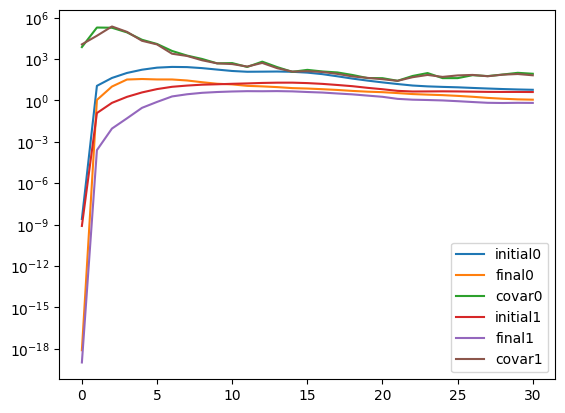

In [6]:
# w_gt_averaged = regularization.batch_average_over_shells(jnp.abs(W_initial.T)**2, gt_results.volume_shape, 0 )
W_averaged = regularization.batch_average_over_shells(jnp.abs(W.T)**2, gt_results.volume_shape, 0 )
W_prior_from_covar_averaged = regularization.batch_average_over_shells(jnp.abs(W_prior_from_covar.T)**2, gt_results.volume_shape, 0 )


for i in range(2):
    # plt.figure()
    # plt.semilogy(W_prior[i], label = 'prior' + str(i)   )
    plt.semilogy(w_gt_averaged[i], label = 'initial' + str(i)   )
    plt.semilogy(W_averaged[i], label = 'final' + str(i))
    plt.semilogy(W_prior_from_covar_averaged[i], label = 'covar' + str(i))
plt.legend()
plt.show()


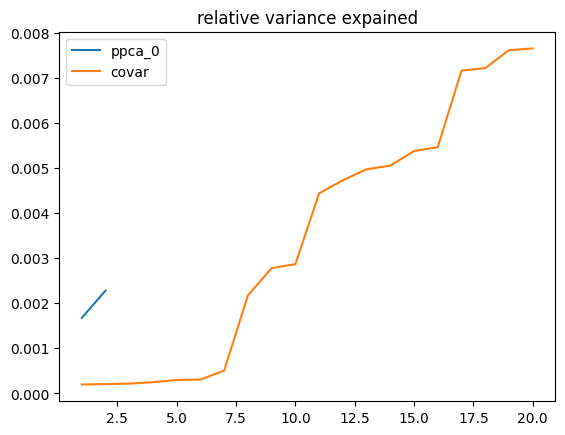

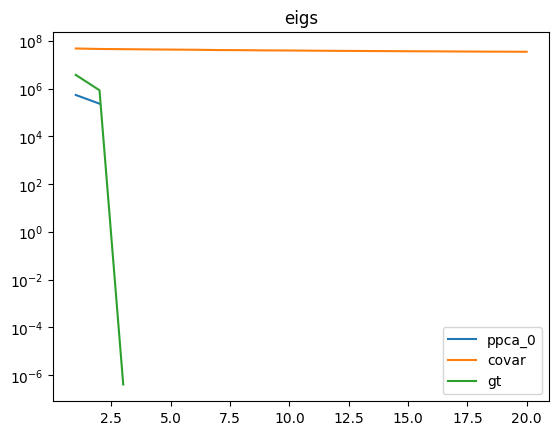

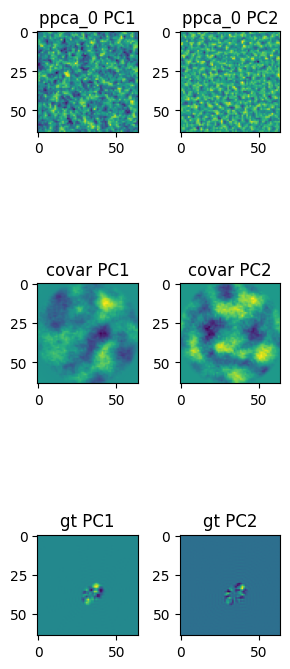

In [7]:
# Load results


# load ground turths
# sim_directory = f"/home/mg6942/recovar/little_dataset/"
# reload(synt)
synt = synthetic_dataset.load_heterogeneous_reconstruction(output_folder + 'simulation_info.pkl')
u_gt, s_gt, vh = synt.get_vol_svd(contrasted = False, real_space = False, random_svd_pcs = 200)
s_gt = s_gt**2


from recovar import output
import numpy as np
import recovar
k =0 
take_n_pcs = 20

# u['ppca'] = u_ppca
# s['ppca'] = s_ppca

u['covar'] = u_covar
s['covar'] = s_covar

# Compute error metrics and plot
angles = {}
rel_var = {}
norm_var = {}

from recovar import metrics
import matplotlib.pyplot as plt
u['gt'] = u_gt
s['gt'] = s_gt
for key in u:
    if key == 'gt':
        continue
    angles[key] = recovar.metrics.subspace_angles(u_gt ,u[key], max_rank = 20)
    variance, rel_var[key], norm_var[key] = metrics.get_all_variance_scores(u[key], u_gt, s_gt)

b = 20
def plot_dict(u_dict, title, max_size = b, log_scale = False):
    plt.figure()
    for key in u_dict.keys():
        max_size_this = np.min([max_size, u_dict[key].size])
        plt.plot(np.arange(1, max_size_this+1), u_dict[key][:max_size_this], label = key)
    plt.legend()
    plt.title(title)
    if log_scale:
        plt.yscale('log')

# plot_dict(angles, 'angle error')
plot_dict(rel_var, 'relative variance expained')
# plot_dict(norm_var, 'normalized variance expained')
plot_dict(s, 'eigs', log_scale = True)


fig, axes = plt.subplots( len(u.keys()), 2, figsize=(3, 8))

for i, u_key in enumerate(u.keys()):

    # Plot PPCA components
    axes[i, 0].imshow(cryos[0].get_proj(u[u_key][:,0].reshape(-1)))
    axes[i, 0].set_title(f'{u_key} PC1')
    axes[i, 1].imshow(cryos[0].get_proj(u[u_key][:,1].reshape(-1)))
    axes[i, 1].set_title(f'{u_key} PC2')

plt.tight_layout()
plt.show()


In [8]:
import pywt

In [9]:
import pyproximal
import numpy as np
z = np.random.randn(10)
pyproximal.L1().prox(z, 0.1)




array([ 0.60500021, -1.07839777, -0.38126848, -0.34443889,  1.40065274,
       -0.41726466, -1.41242926, -1.74274682,  1.56789118,  0.9744777 ])

In [10]:
from recovar.ppca import Wavelet_multilvl
volume_shape = cryos[0].volume_shape
basis = Wavelet_multilvl(volume_shape, 'db1')
mean_coeffs = basis.to_basis(mean_estimate[None])


In [ ]:

import numpy as np
import pywt


    
volume_size = cryos[0].volume_size
mean_real = (ftu.get_idft3(mean_estimate.reshape(volume_shape)) * np.sqrt(volume_size)).real
variance_estimate_coeffs, level_results = wavelet_avg_square_by_level_both(mean_real, wavelet_type='db1')
laplace_coeff_estimate = jnp.sqrt(variance_estimate_coeffs/2)




a6 (Approximation): 1 coeffs, avg square: 2717769.651531
d6 (Detail): 7 coeffs, avg square: 107330.976500
d5 (Detail): 56 coeffs, avg square: 343371.113885
d4 (Detail): 448 coeffs, avg square: 93043.762971
d3 (Detail): 3584 coeffs, avg square: 11321.106413
d2 (Detail): 28672 coeffs, avg square: 1340.656307
d1 (Detail): 229376 coeffs, avg square: 140.515741


In [12]:
# admm_wavelet(lhs, rhs, sigma, mu, niter, volume_shape, normal_size, X0)

In [13]:
# means, mean_prior, _  = homogeneous.get_mean_conformation_relion(cryos, 2*batch_size, noise_variance = noise_variance,  use_regularization = False)


In [14]:
from recovar import relion_functions
disc_type = 'linear_interp'
ft_ctf, ft_y = relion_functions.relion_style_triangular_kernel(
    cryo, noise_variance.astype(np.float32), batch_size, disc_type=disc_type
)


In [15]:
import recovar
import recovar.admm_test
reload(recovar)
reload(recovar.admm_test)

X0= mean_estimate.reshape(volume_shape)
X0_flatten = X0.flatten().reshape( -1, 1)
sigma =  (np.array(1/laplace_coeff_estimate) * 1e-16).reshape(  -1, 1)

# np.linalg.norm(prox_wavelet.prox(X0_flatten, 1) - X0_flatten)



JAX backend: gpu
JAX devices: [CudaDevice(id=0)]
JAX backend: gpu
JAX devices: [CudaDevice(id=0)]


In [16]:
# np.linalg.norm(prox_wavelet.prox(X0_flatten, 1) - X0_flatten)
reload(recovar.admm_test)
reload(recovar)
from recovar.admm_test import LeastSquareFromNormalEqs
lhs = ft_ctf.reshape(volume_size, 1,1)
rhs = ft_y.reshape(volume_size, 1)
sigma = np.mean( (np.array(1/laplace_coeff_estimate) ).reshape(  -1, 1) )
prox_wavelet = recovar.admm_test.WaveletL1(None, volume_shape, 'db1', sigma=sigma)
prox_lstsr = LeastSquareFromNormalEqs(X0_flatten.shape, lhs, rhs)
np.linalg.norm(prox_lstsr.prox(X0_flatten, 1) - X0_flatten)


JAX backend: gpu
JAX devices: [CudaDevice(id=0)]


np.float64(9.362230759308403)

In [17]:
X0.shape

(64, 64, 64)

In [18]:
y1 = prox_lstsr.prox(X0_flatten, 1)
print(y1.shape)
print('done with lstsr')
y2 = prox_wavelet.prox(y1, 1)
print(y2.shape)
print('done with wavelet')
y3 = prox_lstsr.prox(y2, 1)
print('done with lstsr 2')

for k in range(10):
    y3 = prox_lstsr.prox(y2, 1)
    y2 = prox_wavelet.prox(y3, 1)
    print(y3.shape)

(262144, 1)
done with lstsr
(262144, 1)
done with wavelet
done with lstsr 2
(262144, 1)
(262144, 1)
(262144, 1)
(262144, 1)
(262144, 1)
(262144, 1)
(262144, 1)
(262144, 1)
(262144, 1)
(262144, 1)


In [19]:
asdsadsa

NameError: name 'asdsadsa' is not defined

In [ ]:
X0_flatten.shape

(262144, 1)

In [ ]:
from pyproximal.optimization.primal import ADMM

# Run ADMM optimization
X_rec = ADMM(
    prox_lstsr, 
    prox_wavelet, 
    x0=X0_flatten,
    tau=1e-2, 
    niter=20,
    show = True
)[0]

# X_rec = X_rec.reshape(normal_size)
# X0 = X0_flatten
# total_loss, data_loss, reg_loss = compute_total_loss(X0, prox_lstsr, prox_wavelet, mu)
# print(f"  Initial losses: total={total_loss:.6f}, data={data_loss:.6f}, reg={reg_loss:.6f}")

# # Compute final losses
# total_loss, data_loss, reg_loss = compute_total_loss(X_rec, prox_lstsr, prox_wavelet, mu)
# print(f"  Final losses: total={total_loss:.6f}, data={data_loss:.6f}, reg={reg_loss:.6f}")


ADMM
---------------------------------------------------------
Proximal operator (f): <class 'recovar.admm_test.LeastSquareFromNormalEqs'>
Proximal operator (g): <class 'recovar.admm_test.WaveletL1'>
tau = 1.000000e-02	niter = 20

   Itn       x[0]          f           g       J = f + g
done with lstsr prox
done with wavelet prox
     1   0.00000e+00  -1.619e-03   4.441e+00   4.440e+00
done with lstsr prox
done with wavelet prox
     2  -2.59915e-06   4.694e-03   6.811e-01   6.858e-01
done with lstsr prox
done with wavelet prox
     3  -3.89901e-06   7.064e-03   1.022e+00   1.029e+00
done with lstsr prox
done with wavelet prox
     4  -5.19860e-06   9.449e-03   1.362e+00   1.371e+00
done with lstsr prox
done with wavelet prox
     5  -6.49813e-06   1.185e-02   1.702e+00   1.714e+00
done with lstsr prox
done with wavelet prox
     6  -7.79758e-06   1.427e-02   2.043e+00   2.057e+00
done with lstsr prox
done with wavelet prox
     7  -9.09698e-06   1.670e-02   2.383e+00   2.400e+00
done 

In [ ]:
x0 = X0_flatten
proxg = prox_wavelet
proxf = prox_lstsr
niter = 1
gfirst = False
tau = 0.9
callback = None
show = True
x = x0.copy()
u = z = np.zeros_like(x)
for iiter in range(niter):
    if gfirst:
        z = proxg.prox(x + u, tau)
        x = proxf.prox(z - u, tau)
    else:
        x = proxf.prox(z - u, tau)
        z = proxg.prox(x + u, tau)
    u = u + x - z

    # run callback
    if callback is not None:
        if callbackz:
            callback(x, z)
        else:
            callback(x)
    if show:
        if iiter < 10 or niter - iiter < 10 or iiter % (niter // 10) == 0:
            pf, pg = proxf(x), proxg(x)
            msg = '%6g  %12.5e  %10.3e  %10.3e  %10.3e' % \
                    (iiter + 1, np.real((x[0])),
                    pf, pg, pf + pg)
            print(msg)
if show:
    print('\nTotal time (s) = %.2f' % (time.time() - tstart))
    print('---------------------------------------------------------\n')
# return x, z



done with lstsr prox
done with wavelet prox
     1   0.00000e+00   1.002e-01   4.002e-14   1.002e-01


/tmp/ipykernel_174857/2343359162.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  msg = '%6g  %12.5e  %10.3e  %10.3e  %10.3e' % \


NameError: name 'tstart' is not defined

In [ ]:
proxf(x)

3.5447167760368226

In [ ]:
proxg(x)

In [ ]:
lhs = ft_ctf.reshape(volume_size, 1,1)
rhs = ft_y.reshape(volume_size, 1)
sigma =  (np.array(1/laplace_coeff_estimate) * 1).reshape(  -1, 1)
# X0= X0.flatten().reshape( -1, 1)
reload(recovar)
reload(recovar.admm_test)
from recovar.admm_test import admm_wavelet
z = recovar.admm_test.admm_wavelet(lhs, rhs, sigma, 0.09, 20, volume_shape, rhs.shape, X0_flatten)

JAX backend: gpu
JAX devices: [CudaDevice(id=0)]
Running ADMM with wavelet L1 regularization...
  Parameters: sigma=[[0.00085784]
 [0.00431671]
 [0.00431671]
 ...
 [0.11930331]
 [0.11930331]
 [0.11930331]], tau=0.09, niter=20
  Volume shape: (64, 64, 64)
  Normal size: (262144, 1)
ADMM
---------------------------------------------------------
Proximal operator (f): <class 'recovar.admm_test.LeastSquareFromNormalEqs'>
Proximal operator (g): <class 'recovar.admm_test.WaveletL1'>
tau = 9.000000e-02	niter = 20

   Itn       x[0]          f           g       J = f + g
     1   0.00000e+00  -1.235e-02   4.009e+01   4.008e+01
     2  -3.28842e-06  -1.480e-01   5.901e+00   5.753e+00
     3  -4.94519e-06  -2.202e-01   8.843e+00   8.623e+00
     4  -6.59136e-06  -2.911e-01   1.179e+01   1.150e+01
     5  -8.23537e-06  -3.607e-01   1.473e+01   1.437e+01
     6  -9.87723e-06  -4.292e-01   1.768e+01   1.725e+01
     7  -1.15169e-05  -4.963e-01   2.062e+01   2.013e+01
     8  -1.31545e-05  -5.623e-0

In [25]:
reload(recovar)
from recovar import prox_test
reload(recovar.prox_test)
# 1) LeastSquareFromNormalEqs
# prox_ls = LeastSquareFromNormalEqs(dim=normal_size, lhs=lhs, rhs=rhs)
results = recovar.prox_test.run_prox_object_tests(prox_lstsr, tau=0.3, x_shape_hint=X0_flatten.shape)

# 2) WaveletL1
# prox_wav = WaveletL1(dim=normal_size, volume_shape=volume_shape, wavelet_type='db1', sigma=1.0)
results_wav = recovar.prox_test.run_prox_object_tests(prox_wavelet, tau=0.3, x_shape_hint=X0_flatten.shape)


[objective decrease] False
[firm nonexpansive] True
[Moreau identity] True
[quadratic normal-eqs residual] True
[wavelet L1 KKT] True

==> OVERALL: FAIL ❌


ValueError: cannot reshape array of size 262144 into shape (262144,64,64,64)

In [ ]:
pdb

In [ ]:
import numpy as np

def _to_numpy(x):
    try:
        import jax.numpy as jnp
        if isinstance(x, jnp.ndarray):
            return np.array(x)
    except Exception:
        pass
    return np.array(x)

def _infer_shape(prox_obj, x_shape_hint):
    if hasattr(prox_obj, "dim") and prox_obj.dim is not None:
        return tuple(prox_obj.dim)
    if x_shape_hint is not None:
        return tuple(x_shape_hint)
    return (256,)

def _firm_nonexpansive(prox_obj, tau, vec_len, trials=80, seed=0):
    rng = np.random.default_rng(seed)
    for _ in range(trials):
        v = rng.standard_normal(vec_len)
        w = rng.standard_normal(vec_len)
        pv = _to_numpy(prox_obj.prox(v.copy(), tau)).reshape(-1)
        pw = _to_numpy(prox_obj.prox(w.copy(), tau)).reshape(-1)
        lhs = np.vdot(pv - pw, pv - pw).real
        rhs = np.vdot(pv - pw, v - w).real + 1e-12
        if lhs - rhs > 1e-6 * (1 + abs(rhs)):
            return False
    return True

def _moreau_identity(prox_obj, tau, vec_len, trials=20, seed=1):
    if not hasattr(prox_obj, "proxdual"):
        return True
    rng = np.random.default_rng(seed)
    for _ in range(trials):
        v = rng.standard_normal(vec_len)
        x = _to_numpy(prox_obj.prox(v.copy(), tau)).reshape(-1)
        y = _to_numpy(prox_obj.proxdual(v.copy(), tau)).reshape(-1)
        err = np.linalg.norm(x + tau * y - v) / (np.linalg.norm(v) + 1e-12)
        if err > 1e-7:
            return False
    return True

def _check_quadratic_normal_eqs(prox_obj, tau):
    # For LeastSquareFromNormalEqs
    if not all(hasattr(prox_obj, a) for a in ("lhs", "rhs", "dim")):
        return True
    lhs = _to_numpy(prox_obj.lhs)
    rhs = _to_numpy(prox_obj.rhs)
    dim = tuple(prox_obj.dim)
    n_vol, n_basis = lhs.shape[0], lhs.shape[-1]
    rng = np.random.default_rng(123)
    v = rng.standard_normal(int(np.prod(dim)))
    y = _to_numpy(prox_obj.prox(v.copy(), tau))
    V = v.reshape(dim)
    Y = y.reshape(dim)
    I = np.eye(n_basis)
    for i in range(n_vol):
        r = (I + tau * lhs[i]) @ Y[i] - (V[i] + tau * rhs[i])
        if np.linalg.norm(r) / (1 + np.linalg.norm(V[i] + tau * rhs[i])) > 1e-8:
            return False
    return True

def _check_wavelet_l1_kkt(prox_obj, tau):
    # For WaveletL1: uses prox_obj.dim (not x_shape_hint!)
    if not (hasattr(prox_obj, "wavelet") and hasattr(prox_obj, "sigma") and hasattr(prox_obj, "dim")):
        return True
    W = prox_obj.wavelet
    sigma = float(prox_obj.sigma)
    dim = tuple(prox_obj.dim)               # (volume_size, n_basis)
    rng = np.random.default_rng(7)
    v = rng.standard_normal(int(np.prod(dim)))
    xstar = _to_numpy(prox_obj.prox(v.copy(), tau)).reshape(dim)
    # Replicate your orientation: basis_stack = x.T
    z_all = W.to_basis(xstar.T)             # (n_basis, n_coeffs)
    z = z_all.T                             # (n_coeffs, n_basis)
    s = np.sign(z); s[np.isclose(z, 0.0)] = 0.0
    WT_s = W.to_image(s.T).T                # back to (volume_size, n_basis)
    r = (xstar - v.reshape(dim)) + tau * sigma * WT_s
    kkt_err = np.linalg.norm(r.ravel()) / (1 + np.linalg.norm(v))
    return kkt_err < 1e-6

def run_prox_object_tests(prox_obj, tau=0.3, x_shape_hint=None, verbose=True):
    shape = _infer_shape(prox_obj, x_shape_hint)
    vec_len = int(np.prod(shape))

    # smoke: size + objective decrease if __call__
    rng = np.random.default_rng(99)
    v = rng.standard_normal(vec_len)
    xstar = _to_numpy(prox_obj.prox(v.copy(), tau)).reshape(-1)
    assert xstar.size == vec_len, "prox changed the total size."

    try:
        f_v = float(prox_obj(v.copy()))
        f_x = float(prox_obj(xstar.copy()))
        F_v = tau * f_v                      # since 0.5*||v-v||^2 = 0
        F_x = 0.5 * np.linalg.norm(xstar - v)**2 + tau * f_x
        obj_ok = (F_x <= F_v + 1e-8 * (1 + abs(F_v)))
    except Exception:
        obj_ok = True
    if verbose: print(f"[objective decrease] {obj_ok}")

    firm_ok   = _firm_nonexpansive(prox_obj, tau, vec_len)
    if verbose: print(f"[firm nonexpansive] {firm_ok}")

    moreau_ok = _moreau_identity(prox_obj, tau, vec_len)
    if verbose: print(f"[Moreau identity] {moreau_ok}")

    quad_ok   = _check_quadratic_normal_eqs(prox_obj, tau)
    if verbose: print(f"[quadratic normal-eqs residual] {quad_ok}")

    wav_ok    = _check_wavelet_l1_kkt(prox_obj, tau)
    if verbose: print(f"[wavelet L1 KKT] {wav_ok}")

    all_ok = obj_ok and firm_ok and moreau_ok and quad_ok and wav_ok
    if verbose: print(f"\n==> OVERALL: {'PASS ✅' if all_ok else 'FAIL ❌'}")
    return {
        "objective_decrease": obj_ok, "firm_nonexpansive": firm_ok,
        "moreau_identity": moreau_ok, "quadratic_residual": quad_ok,
        "wavelet_kkt": wav_ok, "all_ok": all_ok,
    }


# Use the operator’s own dim so shapes line up with its internal reshape
results_ls  = run_prox_object_tests(prox_lstsr,   tau=0.3, x_shape_hint=prox_lstsr.dim)
results_wav = run_prox_object_tests(prox_wavelet, tau=0.3, x_shape_hint=prox_wavelet.dim)



[objective decrease] False


[firm nonexpansive] True


MemoryError: Unable to allocate 1.00 TiB for an array with shape (262144, 262144) and data type complex128

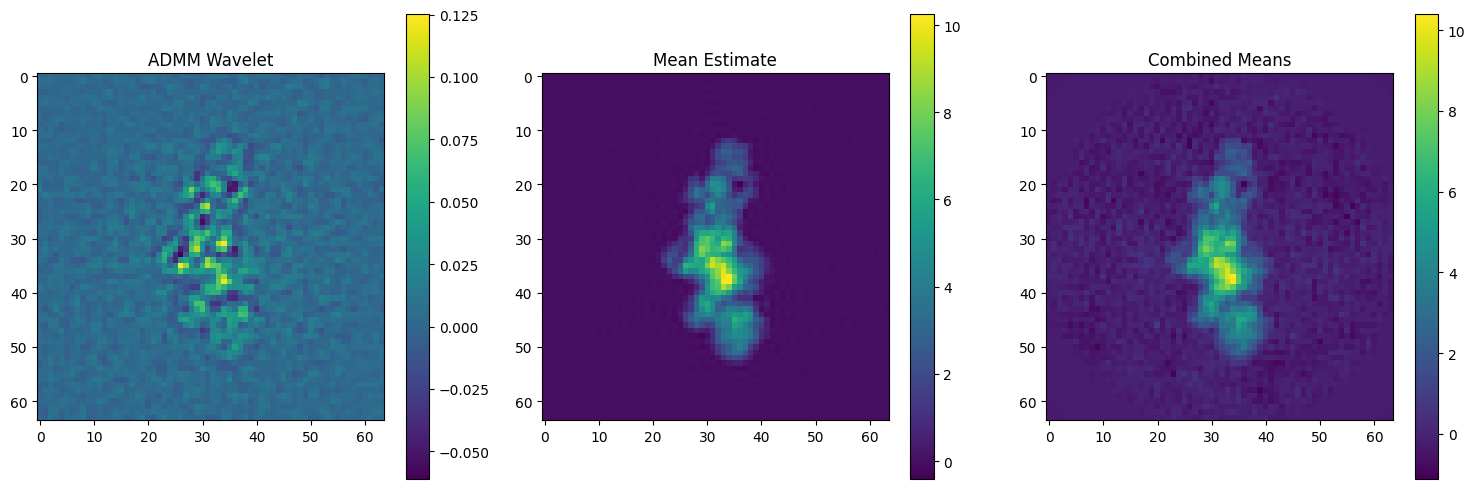

In [ ]:
# Create figure with 3 subplots side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Get projections
proj1 = cryos[0].get_proj(z)
proj2 = cryos[0].get_proj(mean_estimate)
proj3 = cryos[0].get_proj(means['combined'])

# Plot each with its own scale
im1 = ax1.imshow(proj1)
ax1.set_title('ADMM Wavelet')
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(proj2)
ax2.set_title('Mean Estimate') 
plt.colorbar(im2, ax=ax2)

im3 = ax3.imshow(proj3)
ax3.set_title('Combined Means')
plt.colorbar(im3, ax=ax3)

plt.tight_layout()


In [ ]:
ft_y.shape

(262144,)

In [ ]:
import pywt
reload(recovar)
from recovar.sparse_PCA import Wavelet_multilvl
volume_shape = cryos[0].volume_shape
basis = Wavelet_multilvl(volume_shape, 'db1')
# pywt.wavelist()

In [ ]:
volume_size = cryos[0].volume_size
b = 5
gt = np.random.randn (volume_size, 5) * (np.random.rand(volume_size, 5) < 0.1)



In [ ]:
b = 5
lhs = np.random.randn(volume_size, b, b)
rhs = np.random.randn(volume_size, b)

In [ ]:
volume_size = cryos[0].volume_size

prox_lstsr = LeastSquareFromNormalEqs(volume_size, lhs, rhs)
prox_wavelet = WaveletL1(volume_size, )

X_rec = ADMM(prox_lstsr, prox_wavelet, x0=X0.flatten(), tau=0.9, niter=200)[0]
X_rec = X_rec.reshape(normal_size)




In [ ]:
import numpy as np
b = 10
n = 10
rhs = np.random.randn(b, n)
lhs = np.random.randn(b,n,n)



In [ ]:
r"""
Non-rigid structure-from-motion (NRSfM)
=======================================
In computer vision, structure-from-motion (SfM) is an imaging technique for
estimating three-dimensional structures from two-dimensional images. Theoretically,
the problem is generally well-posed when considering rigid objects, meaning
that the objects do not move or deform in the scene. However, non-static scenes
are still relevant and have gained increased popularity among researchers in
recent years. This is known as *non-rigid structure-from-motion*.

In this tutorial, we will consider motion capture (MOCAP). This is a special
case, where we use images from multiple camera views to compute the 3D positions
of specifically designed markers that track the motion of a person (or object)
performing various tasks.

Non-rigid shapes
****************
To make the problem well-posed, one has to control the complexity of
the deformations using some minor assumptions on the possible space of object
shapes. This is not a weird thing to do: consider e.g. the human body,
we have different joints that bend and turn in a finite amount of ways; the
skeleton itself is rigid and not capable of such deformations. For this reason,
Bregler et al. [1]_ suggested that all movements (or shapes) can be represented
by a low-dimensional basis. In the context of motion capture, this means that
every movement a person does can be considered a combination of core movements
(or basis shapes).

Mathematically speaking, this translates to any motion being a linear combination
of the basis shapes, i.e. assuming there are :math:`K` basis shapes, any non-rigid
shape :math:`X_i` can be written as

    .. math::
        X_i = \sum_{i=1}^K c_{ik}B_k

where :math:`c_{ik}` are the basis coefficients and :math:`B_k` are the basis shapes.
Here, :math:`X_i` is a :math:`3\times N` matrix where each column is a point in
3D space.

The CMU MOCAP dataset
*********************
Let us first try to understand the data we are given. We will use the *Pickup*
instance from the CMU MOCAP dataset, which depicts a person picking something
up from the floor.
"""

# import matplotlib.pyplot as plt
# import matplotlib.animation as animation
import numpy as np
import scipy as sp


plt.close('all')
np.random.seed(0)
data = np.load('../testdata/mocap.npz', allow_pickle=True)
X_gt = data['X_gt']
markers = data['markers'].item()

###############################################################################
# First we view the first 3D poses. In order to easily visualize the person, we
# draw a skeleton between the markers corresponding to certain body parts. Note
# that these are not used in any other way.


def plot_first_3d_pose(ax, X, color='b', marker='o', linecolor='k'):
    ax.scatter(X[0, :], X[1, :], X[2, :], color, marker=marker)
    for j, ind in enumerate(markers.values()):
        ax.plot(X[0, ind], X[1, ind], X[2, ind], '-', color=linecolor)
    ax.set_box_aspect(np.ptp(X[:3, :], axis=1))
    ax.view_init(20, 25)


fig = plt.figure()
ax = fig.add_subplot(projection='3d')
plot_first_3d_pose(ax, X_gt)
plt.tight_layout()

###############################################################################
# Now, we turn the attention to the data the algorithm is given, which is a
# sequence of 2D images from varying views. The goal is to recreate the 3D
# points, such as in the example above, from all timestamps.

M = data['M']
F = int(X_gt.shape[0] / 3)


def _update(f: int):
    X = M[2 * f:2 * f + 2, :]
    lines[0].set_data(X[0, :], X[1, :])
    for j, ind in enumerate(markers.values()):
        lines[j + 1].set_data(X[0, ind], X[1, ind])
    return lines


fig, ax = plt.subplots()
lines = ax.plot([], [], 'r.')
for _ in range(len(markers)):
    lines.append(ax.plot([], [], 'k-')[0])
ax.set(xlim=(-2.5, 2.5), ylim=(-3.5, 3.5))
ax.set_aspect('equal')

ani = animation.FuncAnimation(fig, _update, F, interval=25, blit=True)


###############################################################################
# Note that these are the 2D image correspondences and that the image view is
# constantly changing as it is spinning around. Such motion can be modeled
# with orthographic cameras, which we will discuss next.
#
# Orthographic projections
# ************************
# Assuming that we know the pose of the camera from which the image was taken
# the corresponding 2D image point can be obtained. In the case of rotations,
# we assume the cameras are orthographic, meaning that the image points :math:`x_i`
# are obtained from the relation
#
#     .. math::
#         x_i = R_iX_i
#
# where :math:`R_i` is a :math:`2\times 3` matrix fulfilling :math:`R_iR_i^T=I`.
# Essentially, the :math:`R_i` matrices consists of the top two rows of the
# corresponding rotation matrix.
#
# Now, the task at hand is essentially the inverse problem: to reconstruct the
# 3D points for each point in time from these 2D images.
#
# Treating NRSfM as a low-rank factorization problem
# **************************************************
# One of the main novelties of the paper by Dai et al. [2]_ is to reshape and
# stack the non-rigid shapes :math:`X_i` in a way that allows us to treat the
# problem using methods from low-rank factorization. This is done in the following
# way: first concatenate all rows of :math:`X_i` creating a vector
# :math:`X^\sharp_i` of size :math:`1\times 3N`. Secondly, assuming there are in
# total :math:`F` non-rigid shapes we create the matrix :math:`X^\sharp` of size
# :math:`F\times 3N` by stacking all :math:`X^\sharp_i`. This enables us to decompose
# the newly created matrix :math:`X^\sharp=CB^\sharp` in the low-rank factors
# consisting of the shape coefficients :math:`C` and the basis shapes :math:`B^\sharp`
# (constructed in the same way as :math:`X^\sharp`).
#
# Now, let us implement and visualize this approach.


def stack(X: np.ndarray):
    return np.hstack((X[::3, :], X[1::3, :], X[2::3, :]))


Xi = np.arange(15).reshape((3, 5))
fig, ax = plt.subplots(1, 2)
ax[0].matshow(Xi)
ax[0].set_title(r'$X_i$')
ax[0].axis('off')
ax[1].matshow(stack(Xi))
ax[1].set_title(r'$X_i^\sharp$')
ax[1].axis('off')
plt.tight_layout()

###############################################################################
# Furthermore, we introduce the inverse
# operation, such that :math:`X=\mathcal{U}(X^\sharp)`, where
# :math:`\mathcal{U}` is the "unstacking" operator.


def unstack(Xs: np.ndarray):
    """Inverse operation of stack."""
    m, n = Xs.shape
    m *= 3
    n //= 3
    X = np.zeros((m, n), dtype=Xs.dtype)
    X[::3] = Xs[:, :n]
    X[1::3] = Xs[:, n:2*n]
    X[2::3] = Xs[:, 2*n:3*n]
    return X

###############################################################################
# In many cases, the necessary amount of basis shapes is not known
# *a priori*. Therefore, a suitable objective to try to minimize is
#
#     .. math::
#         \argmin_X \mu \rank(X^\sharp) + \frac{1}{2}\sum_{i=1}^F\|R_iX_i - x_i\|_2^2
#
# or, equivalently,
#
#     .. math::
#         \argmin_X \mu \rank(X^\sharp) + \frac{1}{2}\|RX - M\|_F^2
#
# where :math:`R` is a block-diagonal matrix with :math:`R_i` on the main diagonal,
# whereas :math:`X` and :math:`M` are the concatenations of :math:`X_i` and
# :math:`x_i`, respectively.
#
# Since the rank function is non-convex and discontinuous, it is often replaced
# by a relaxation. In [2]_ the *nuclear norm* :math:`\|\cdot\|_{*}` was used, i.e.
# we seek to minimize
#
#     .. math::
#         \argmin_X \mu \|X^\sharp\|_{*} + \frac{1}{2}\|RX - M\|_F^2 \; .
#
# There are some theoretical justifications for this specific choice of relaxation,
# e.g. the nuclear norm is the convex envelope of the rank function under
# curtain assumptions [3]_.
#
# Solving the relaxed problem
# ***************************
# We will now show how to solve this problem using splitting schemes. Specifically,
# we will use :class:`pyproximal.ADMM` and re-write the objective as
#
#     .. math::
#         \argmin_{X, Z} \mu \|Z^\sharp\|_{*} + \frac{1}{2}\|RX - M\|_F^2,
#
# and add the constraint :math:`X=Z`. This way, the proximal operators
# are simply those of the (stacked) nuclear norm and the Frobenius norm.
# We implement these next:

from pyproximal.ProxOperator import _check_tau
from pyproximal import Nuclear, ProxOperator


class BlockDiagFrobenius(ProxOperator):
    r"""Proximal operator for 1/2 * ||RX - M||_F^2 where R is block-diagonal.
    Note: You could also wrap pyproximal.L2, but this class is used here in
    this tutorial to increase legibility.
    """
    def __init__(self, dim, R, M):
        super().__init__(None, False)
        self.dim = dim
        self.R = R
        self.M = M

    def __call__(self, x):
        X = x.reshape(self.dim)
        return 0.5 * np.linalg.norm(self.R @ X - self.M, 'fro') ** 2

    @_check_tau
    def prox(self, x, tau):
        X = x.reshape(self.dim)
        Y = np.zeros_like(X)
        for f, Rf in enumerate(self.R):
            Y[3 * f: 3 * f + 3, :] = np.linalg.solve(
                tau * Rf.T @ Rf + np.eye(3),
                tau * Rf.T @ self.M[2 * f:2 * f + 2, :] + X[3 * f: 3 * f + 3, :]
            )
        return Y.flatten()


class StackedNuclear(Nuclear):
    r"""Proximal operator for the stacked nuclear norm."""
    def __init__(self, dim, sigma=1.):
        super().__init__(dim, sigma)
        self.unstacked_dim = (dim[0] * 3, dim[1] // 3)

    def __call__(self, x):
        X = stack(x.reshape(self.unstacked_dim))
        return super().__call__(X.ravel())

    def prox(self, x, tau):
        X = stack(x.reshape(self.unstacked_dim))
        x = super().prox(X.ravel(), tau)
        X = unstack(x.reshape(self.dim))
        return X.ravel()


###############################################################################
# Now we are ready to solve the problem using ADMM.

from pyproximal.optimization.primal import ADMM


mu = 1
R = data['R']
Rblk = sp.linalg.block_diag(*R)
M = Rblk @ X_gt
N = M.shape[1]
normal_size = (3*F, N)
stacked_size = (F, 3*N)
X0 = np.zeros(normal_size)
proxf = BlockDiagFrobenius(normal_size, R, M)
proxg = StackedNuclear(stacked_size, mu)
X_rec = ADMM(proxf, proxg, x0=X0.flatten(), tau=0.9, niter=200)[0]
X_rec = X_rec.reshape(normal_size)

###############################################################################
# Let us compare the results with the ground truth data.
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
plot_first_3d_pose(ax, X_gt)
plot_first_3d_pose(ax, X_rec, color='r', marker='v', linecolor='r')
plt.tight_layout()

###############################################################################
# Furthermore, we compute some statistics on the reconstruction performance. You
# can vary the regulation strength :math:`\mu` to see if you can achieve better
# performance yourself!
print(f'Datafit: {np.linalg.norm(Rblk @ X_rec - M, "fro")}')
print(f'Distance to GT: {np.linalg.norm(X_rec - X_gt, "fro")}')

###############################################################################
# One issue with the nuclear norm is that you have the hyperparameter
# :math:`\mu` that regulates the impact of the datafit vs. model assumption.
# When :math:`\mu=0` the datafit is perfect, but there would be no enforcement
# of the basis shapes, leading to severe over-fitting. On the other end, as
# :math:`\mu\to\infty` the reconstruction turns towards the zero matrix, thus
# completely ignoring the given data.
#
# Later publications have tried to mitigate this issue, and have shown that
# the weighted nuclear norm performs even better when the weights are selected
# with care [4]_. Other non-convex relaxations show similar results [5]_.
#
# **References**
#
# .. [1] C. Bregler, A. Hertzmann, and H. Biermann. Recovering non-rigid 3d shape
#    from image streams. In The IEEE Conference on Computer Vision and Pattern
#    Recognition (CVPR), 2000.
# .. [2] Y. Dai, H. Li, and M. He. A simple prior-free method for non-rigid
#    structure-from-motion factorization. International Journal of Computer Vision,
#    107(2):101–122, 2014.
# .. [3] M. Fazel, H. Hindi, and S. P. Boyd. A rank minimization heuristic with
#    application to minimum order system approximation. In the Proceedings of the
#    American Control Conference (ACC), 2001.
# .. [4] S. Kumar. Non-rigid structure from motion: Prior-free factorization method
#    revisited. In The IEEE Winter Conference on Applications of Computer Vision
#    (WACV), 2020.
# .. [5] M. Valtonen Örnhag and C. Olsson. A unified optimization framework for
#    low-rank inducing penalties. In the Proceedings of the IEEE/CVF conference
#    on computer vision and pattern recognition (CVPR), 2020.



NameError: name 'plt' is not defined